In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
import os
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

### Parameters

In [4]:
seed_value = 42
global seed  
seed = seed_value

# Reset seeds for all randomness sources
np.random.seed(seed)
torch.manual_seed(seed)

import random
random.seed(seed)

base_seed = 42
seed_train = base_seed
seed_visualization = base_seed + 1
seed_evaluation = base_seed + 2
seed_test = base_seed + 3

In [5]:
max_inventory = 20

In [6]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [7]:
# OU parameters
u0 = 0.0
xi = 1.0
total_arrivals = 30.0

def m(t, eta):
    return u0 * np.exp(-eta * t)

def v(t, eta):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_aux_integral_for_psi_eta(gamma, eta, fads_proportion):
    """Compute psi for multiple eta values using the discretized integral version."""
    time_grid = np.linspace(0, terminal_time, n_steps)

    v_t = v(time_grid, eta)
    c = gamma * sigma * fads_proportion
    integrand_values = np.exp((c**2) / 2 * v_t)
    aux_integral = terminal_time * np.mean(integrand_values)
    psi = (total_arrivals * terminal_time - phi * terminal_time) / aux_integral

    return psi

psi = compute_aux_integral_for_psi_eta(gamma, eta, fads_proportion)
print("psi value:", psi)

psi value: 14.872343376978963


In [8]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [9]:
fi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [10]:
fi_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=fi_env)
print(fi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


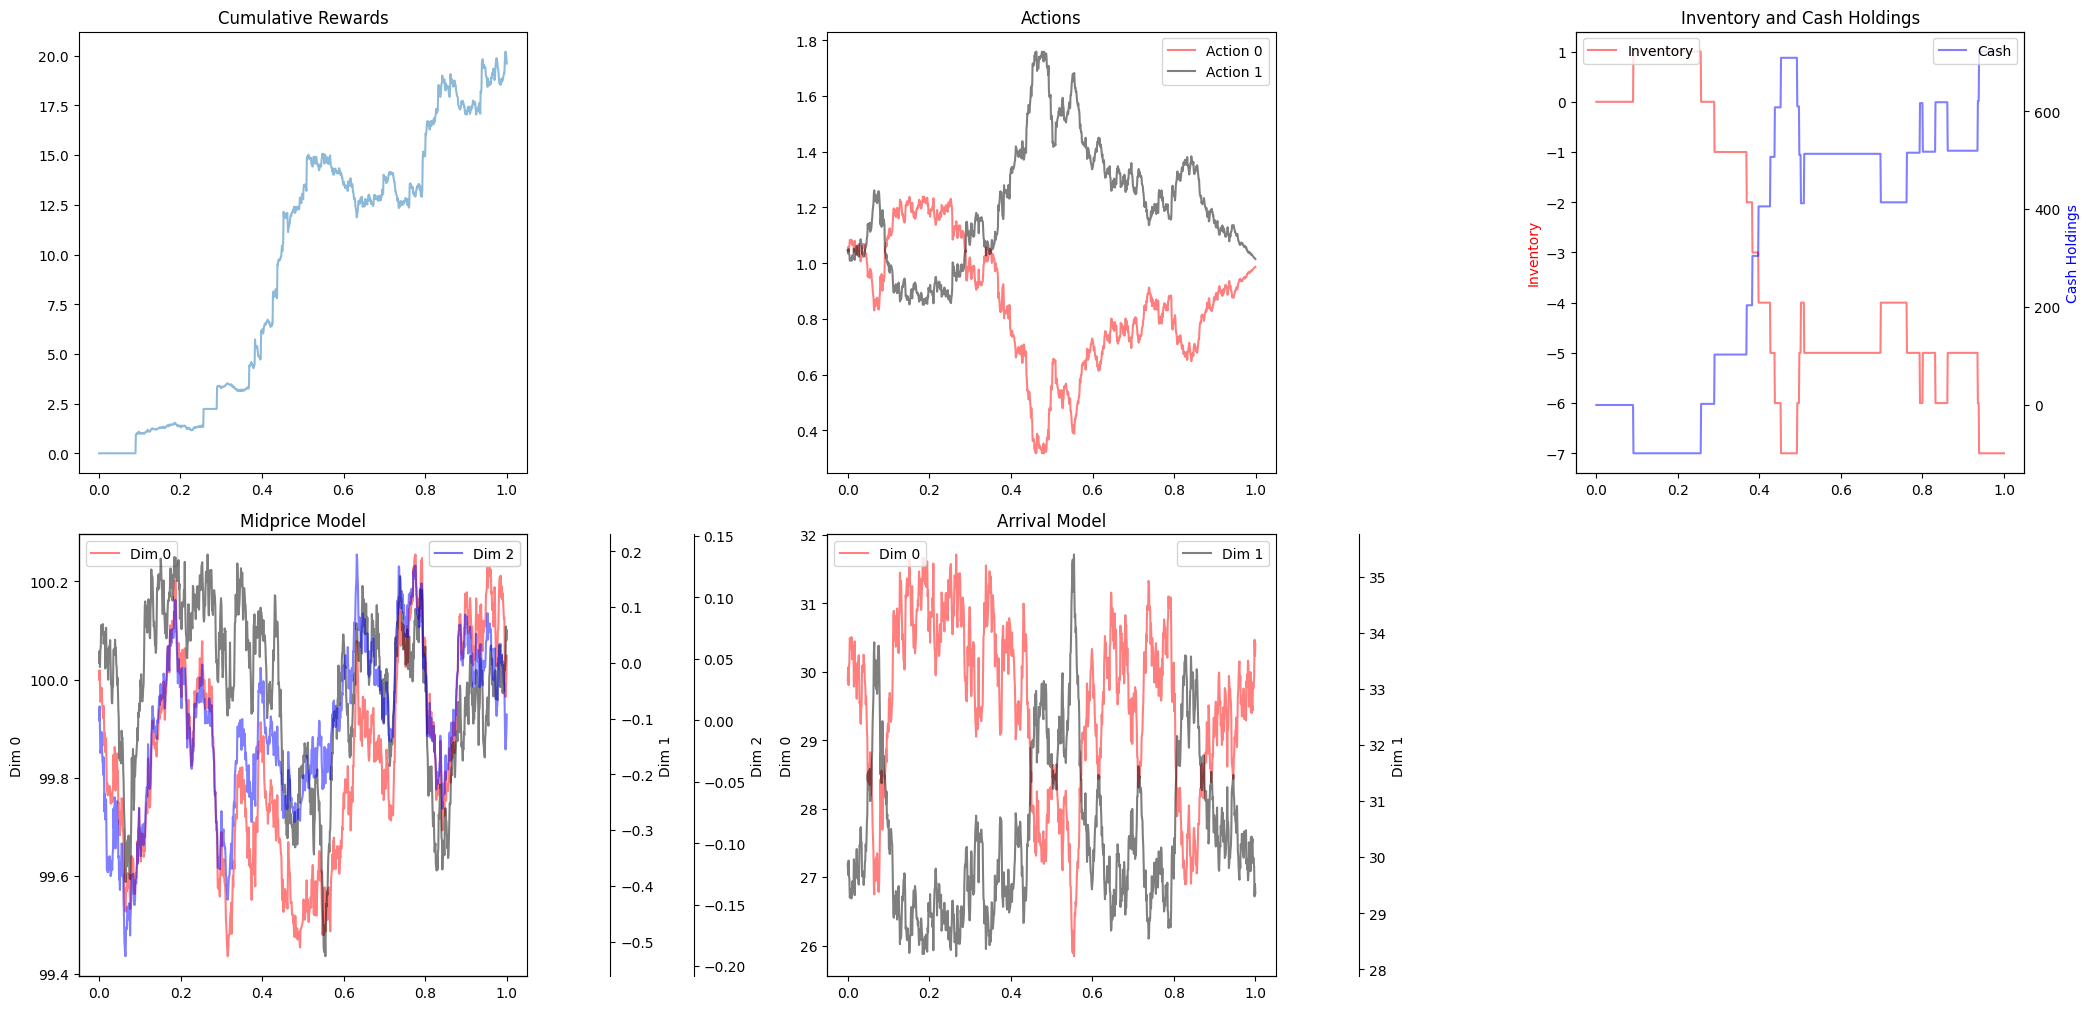

In [11]:
plot_trajectory_extended(fi_env, fi_agent)

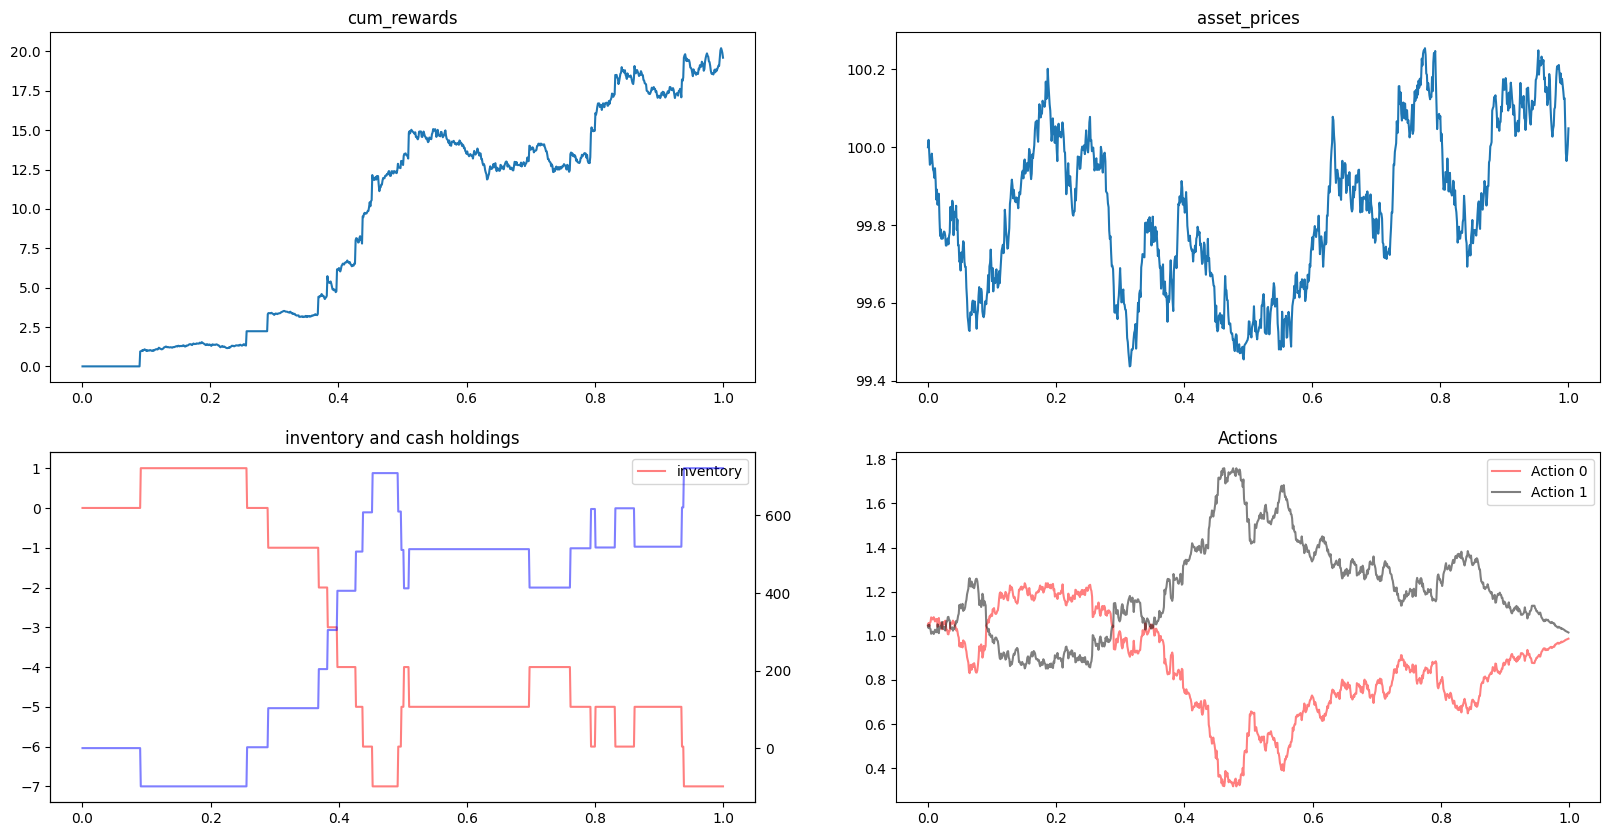

In [12]:
plot_trajectory(fi_env, fi_agent, seed = seed)

In [13]:
num_trajectories = 1000
vec_env_fi = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_agent_fi = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env_fi)

✓ Pre-computed ODE solutions for 1000 time points


In [14]:
observations_fi, actions_fi, rewards_fi = generate_trajectory(vec_env_fi, vec_agent_fi)

In [15]:
results_fi, fig_fi, total_rewards_fi = generate_results_table_and_hist(vec_env=vec_env_fi,agent=vec_agent_fi)

In [16]:
results_fi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.259366,4.896308,-0.098,3.100386


### Rinforncement Learning

#### Random initial inventory

In [17]:
random_initial_inventory = (-6,5)

#### Random start time 

In [18]:

def make_random_start_time_sampler(terminal_time: float):
    """
    Returns a callable that samples an initial time according to:
      - with probability 0.5: uniform in [0, 0.8 * T]
      - with probability 0.5: uniform in [0.8 * T, 0.99 * T]
    
    Parameters
    ----------
    terminal_time : float
        The terminal time T of the episode.
    
    Returns
    -------
    callable
        A function that samples and returns a random start time.
    """
    def _sample_start_time():
        if np.random.rand() < 0.5:
            # 50% chance: early part of episode
            return np.random.uniform(0.0, 0.8 * terminal_time)
        else:
            # 50% chance: near the end of episode
            return np.random.uniform(0.8 * terminal_time, 0.99 * terminal_time)
    return _sample_start_time

In [19]:
def get_rl_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0, seed:int = seed_value
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [20]:
num_trajectories = 1000
reduced_training_indices = [INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX, FADS_INDEX]
rl_env_train = ReduceStateSizeWrapper(get_rl_env(num_trajectories, seed=seed_train), reduced_training_indices)
#rl_env = NormaliseASObservation(rl_env)
sb_rl_env_train = StableBaselinesTradingEnvironment(trading_env=rl_env_train)

# Monitor sb_rl_env
sb_rl_env_train = VecMonitor(sb_rl_env_train)

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):


In [ ]:
rl_env_eval = ReduceStateSizeWrapper(get_rl_env(num_trajectories=1000, seed=seed_evaluation), reduced_training_indices)
sb_rl_env_eval = StableBaselinesTradingEnvironment(trading_env=rl_env_eval)
# Monitor sb_env_eval
sb_rl_env_eval = VecMonitor(sb_rl_env_eval)

### PPO

In [22]:
total_steps = num_trajectories * n_steps * 10 

n_eval_episodes = 256

eval_freq = n_steps * 1

use_normalized_agent = False

In [23]:
# Generate timestamp string
run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
experiment_name = "FIMm_finalVersion_prova"

# Paths with timestamp
tensorboard_logdir = f".././Full_Info_models/tensorboard/PPO-learning-FI/{experiment_name}/{run_id}/"
best_model_path = f".././Full_Info_models/PPO-best-FI/{experiment_name}/{run_id}"

In [24]:
# Make sure directories exist
os.makedirs(tensorboard_logdir, exist_ok=True)
os.makedirs(best_model_path, exist_ok=True)

In [25]:
class EntropyDecayCallback(BaseCallback):
    def __init__(self, initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=10_000_000, verbose=0):
        super().__init__(verbose)
        self.initial_ent_coef = initial_ent_coef
        self.final_ent_coef = final_ent_coef
        self.decay_steps = decay_steps

    def _on_step(self) -> bool:
        progress = min(1.0, self.num_timesteps / self.decay_steps)
        new_ent_coef = self.initial_ent_coef * (1 - progress) + self.final_ent_coef * progress
        self.model.ent_coef = new_ent_coef
        return True

In [26]:
policy_kwargs = dict(
    activation_fn=nn.Tanh,                 
    net_arch=[dict(pi=[256, 256], vf=[256, 256])]
)

n_epochs = 10
learning_rate = 3e-4
gae_lambda = 0.95
clip_range = 0.2
vf_coef = 0.5
max_grad_norm = 0.5

PPO_params = {"policy":'MlpPolicy', "env": sb_rl_env_train, "verbose":1, 
              "policy_kwargs":policy_kwargs, 
              "tensorboard_log":tensorboard_logdir,
              "n_epochs":n_epochs,
              "batch_size": int(n_steps * num_trajectories / 10), 
              "n_steps": int(n_steps),
              "learning_rate": learning_rate,
              "gae_lambda": gae_lambda,
              "clip_range": clip_range,
              "vf_coef": vf_coef,
              "max_grad_norm": max_grad_norm,
                }

#eval_env = get_rl_env(num_trajectories=1)
#eval_env.initial_inventory = 0
callback_params = dict(eval_env=sb_rl_env_eval, n_eval_episodes=n_eval_episodes,
                       eval_freq=eval_freq,
                       best_model_save_path = best_model_path, 
                       deterministic=True)

entropy_decay_callback = EntropyDecayCallback(initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=20_000_000)
callback = CallbackList([EvalCallback(**callback_params), entropy_decay_callback])

#callback = EvalCallback(**callback_params)
model = PPO(**PPO_params, device="cpu")

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


Using cpu device


### Training

In [27]:
print(sb_rl_env_train.observation_space)

Box([-20.          0.         -5.5999999 -10.       ], [ 20.           1.         105.59999847  10.        ], (4,), float64)


In [28]:
model.learn(total_timesteps = total_steps, callback=callback, progress_bar=True) 

Logging to .././Full_Info_models/tensorboard/PPO-learning-FI/FIMm_finalVersion_prova/2025-12-01_12-15-33/PPO_1


Output()

Eval num_timesteps=1000000, episode_reward=-3.26 +/- 6.12

Episode length: 1000.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 1e+03    |
|    mean_reward     | -3.26    |
| time/              |          |
|    total_timesteps | 1000000  |
---------------------------------


...

Eval num_timesteps=10000000, episode_reward=13.15 +/- 4.34

Episode length: 1000.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 1e+03        |
|    mean_reward          | 13.2         |
| time/                   |              |
|    total_timesteps      | 10000000     |
| train/                  |              |
|    approx_kl            | 0.0023232626 |
|    clip_fraction        | 0.0133       |
|    clip_range           | 0.2          |
|    entropy_loss         | -3.13        |
|    explained_variance   | 0.329        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0276       |
|    n_updates            | 90           |
|    policy_gradient_loss | -0.000507    |
|    std                  | 1.16         |
|    value_loss           | 0.23         |
------------------------------------------


New best mean reward!

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 8.55     |
| time/              |          |
|    fps             | 7417     |
|    iterations      | 10       |
|    time_elapsed    | 1348     |
|    total_timesteps | 10000000 |
---------------------------------


### Visualization

In [29]:
def get_rl_env_visualization(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0, seed:int = seed_value
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory = max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [30]:
rl_env_visualization = get_rl_env_visualization(num_trajectories=5, seed=seed_visualization)

In [31]:
ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_visualization, use_normalized_agent=use_normalized_agent)

Generating RL trajectory plot...
env.observation_space: Box([-1.056e+05 -2.000e+01  0.000e+00 -5.600e+00 -1.000e+01 -1.000e+01
  0.000e+00  0.000e+00], [1.056e+05 2.000e+01 1.000e+00 1.056e+02 1.000e+01 1.000e+01 6.000e+01
 6.000e+01], (8,), float32)
env.action_space: Box(0.0, 4.6051702, (2,), float32)


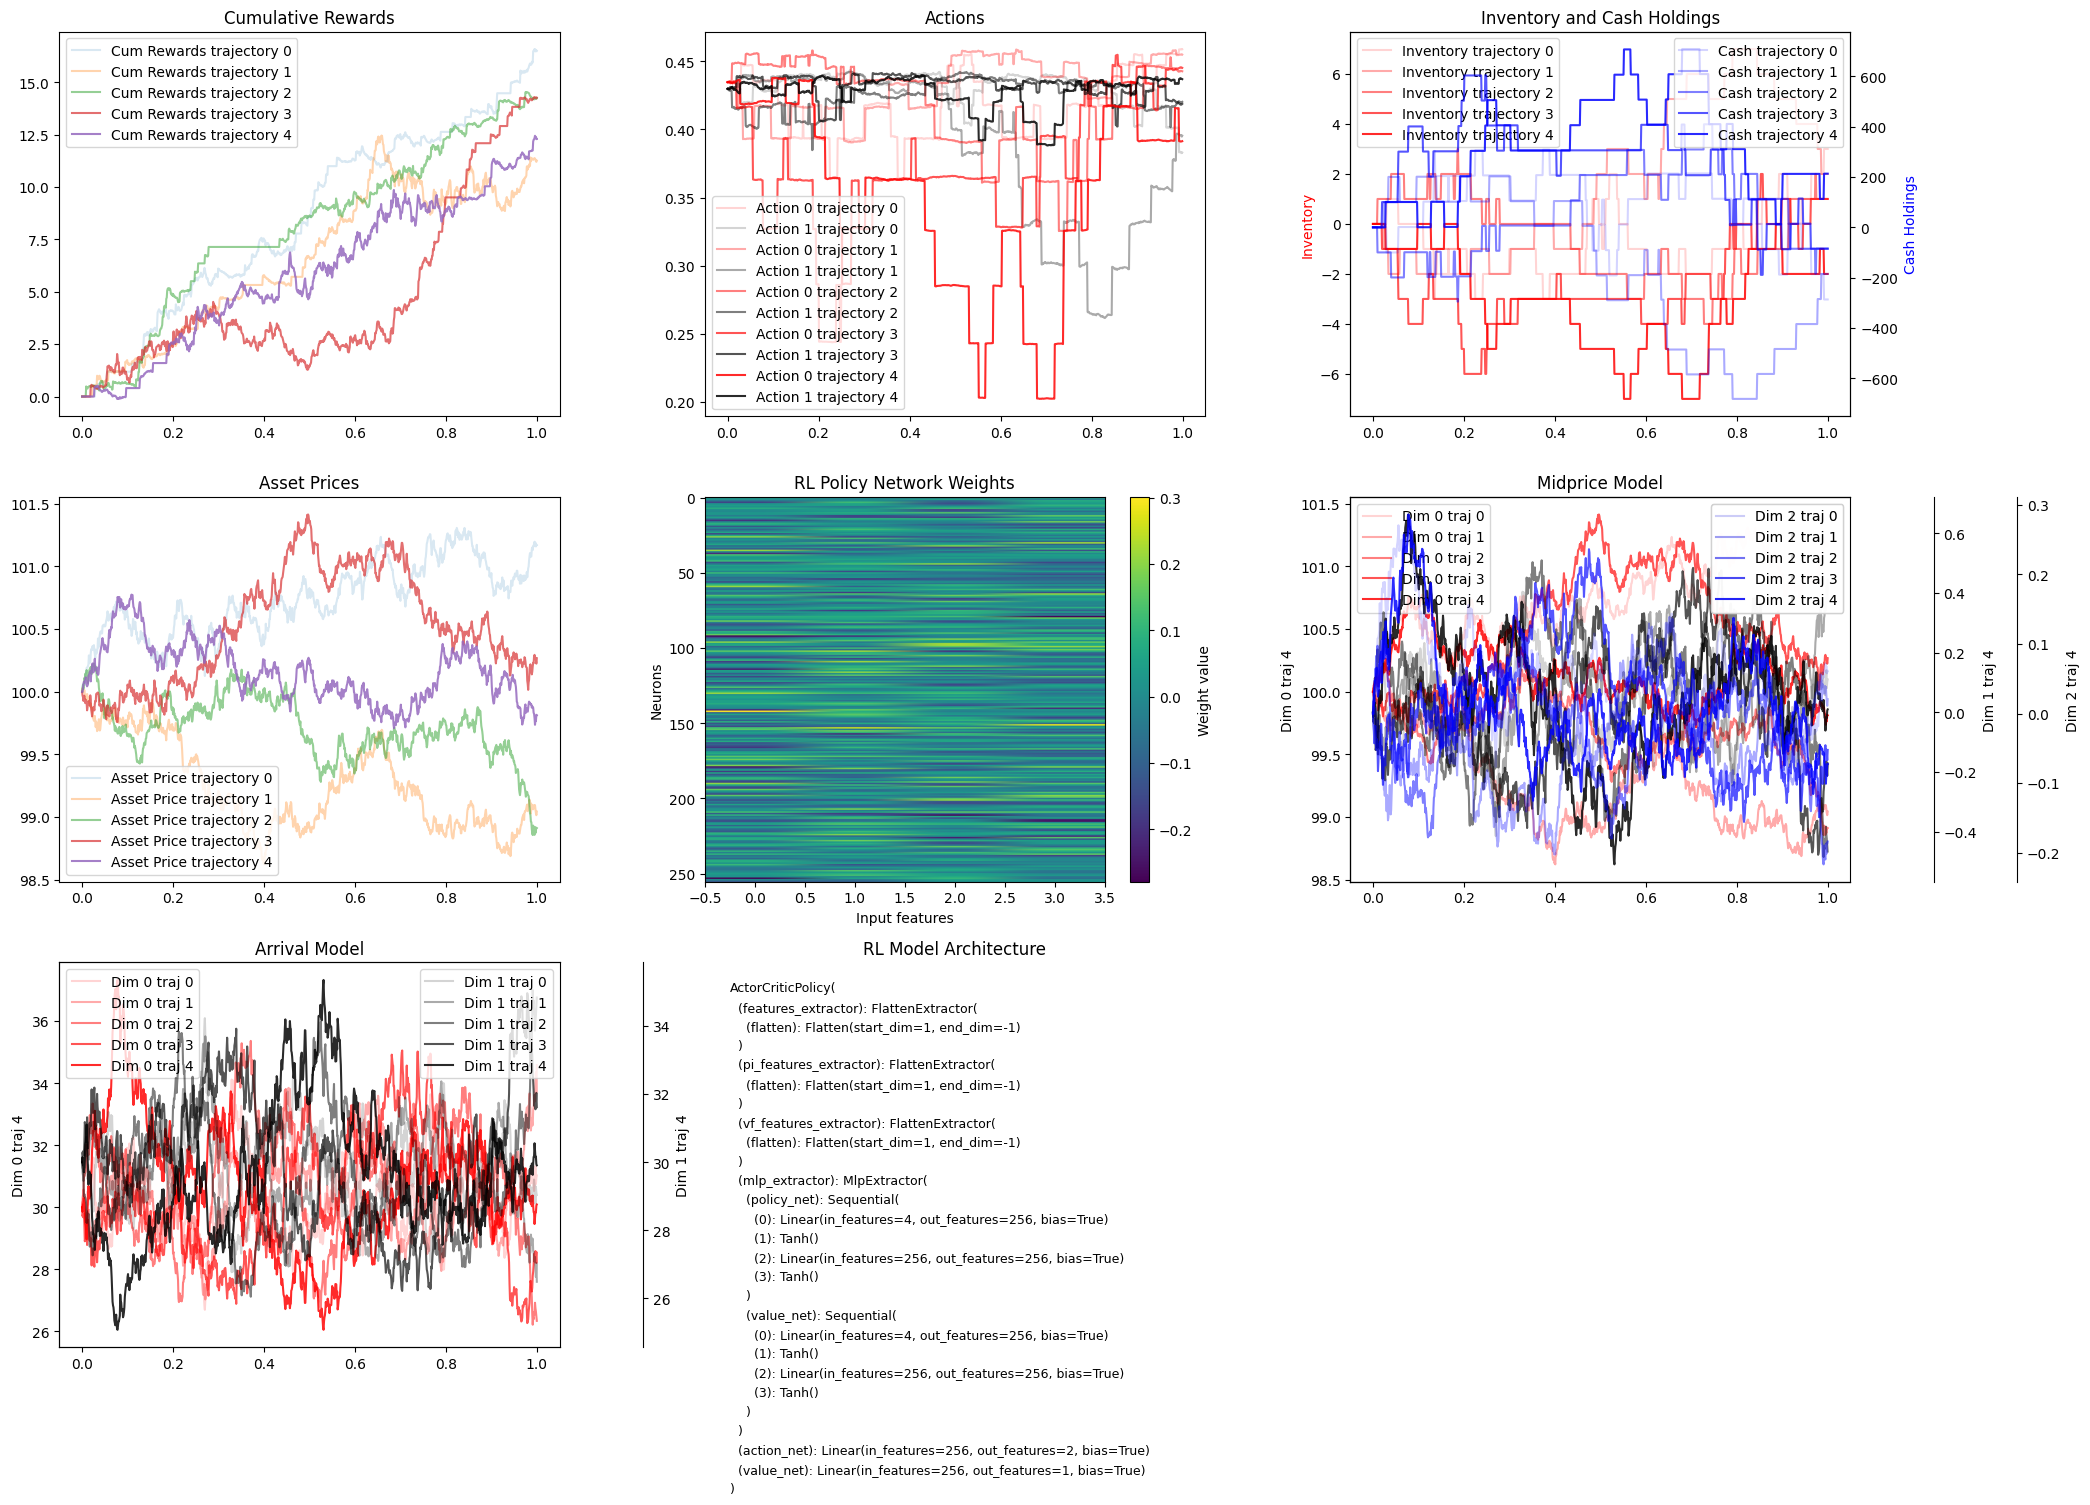

Plot saved to .././Full_Info_models/PPO-best-FI/FIMm_finalVersion_prova/2025-12-01_12-15-33/trajectory_plot.png


In [32]:
# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Create the plot
fig = plot_rl_trajectory_extended(rl_env_visualization, ppo_agent)

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "trajectory_plot.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

In [33]:
rl_env_evaluation = get_rl_env_visualization(num_trajectories=1000, seed=seed_test)

In [34]:
results_rl, fig_rl, total_rewards_rl = generate_results_table_and_hist_rl_fast(vec_env=rl_env_evaluation, rl_agent=ppo_agent, use_normalized_agent=use_normalized_agent )

In [35]:
results_rl

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
RL Agent,0.797681,14.282422,4.56253,-0.096,5.25688


### Bid/Ask spread vs Inventory

In [36]:
def plot_actions_vs_fad_colored(observations, actions, max_traj=None):
    """
    Plot ask (solid markers) and bid (dashed markers) spreads vs fad (Ut),
    with inventory as color shading, looping over multiple trajectories.
    
    Parameters
    ----------
    observations : np.ndarray
        Shape (n_traj, 7, T+1)
    actions : np.ndarray
        Shape (n_traj, 2, T)
    max_traj : int or None
        Maximum number of trajectories to include (default: all)
    """
    n_traj = observations.shape[0]
    print(f"Total trajectories available: {n_traj}")
    if max_traj is None:
        max_traj = n_traj

    all_fad = []
    all_inv = []
    all_ask = []
    all_bid = []

    # Collect data from multiple trajectories
    for traj_idx in range(min(max_traj, n_traj)):
        #print(f"Processing trajectory {traj_idx+1}/{min(max_traj, n_traj)}")
        obs = observations[traj_idx, :, :-1]  # (7, T)
        acts = actions[traj_idx]              # (2, T)
        #[INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX, FADS_INDEX]
        fad = obs[3]          # fad Ut
        inventory = obs[0]    # inventory Q
        bid_spread = acts[0]
        ask_spread = acts[1]

        all_fad.append(fad)
        all_inv.append(inventory)
        all_ask.append(ask_spread)
        all_bid.append(bid_spread)

    # Flatten all trajectories into 1D arrays
    fad = np.concatenate(all_fad)
    inventory = np.concatenate(all_inv)
    ask_spread = np.concatenate(all_ask)
    bid_spread = np.concatenate(all_bid)

    # Plot
    plt.figure(figsize=(10, 6))

    sc1 = plt.scatter(fad, ask_spread, c=inventory, cmap="viridis",
                      alpha=0.6, label="Ask spread", marker="o", s=10)
    sc2 = plt.scatter(fad, bid_spread, c=inventory, cmap="viridis",
                      alpha=0.6, label="Bid spread", marker="x", s=10)

    plt.xlabel("Fad $U_t$")
    plt.ylabel("Spread")
    plt.title("Bid/Ask Spreads vs Fad with Inventory Coloring (all trajectories)")
    plt.legend()
    cbar = plt.colorbar(sc1)
    cbar.set_label("Inventory $Q$")
    plt.grid(True)
    plt.show()

In [37]:
observations_rl, actions_rl, rewards_rl = generate_trajectory_rl(env=rl_env_visualization, rl_agent=ppo_agent, use_normalized_agent=use_normalized_agent)

Total trajectories available: 5


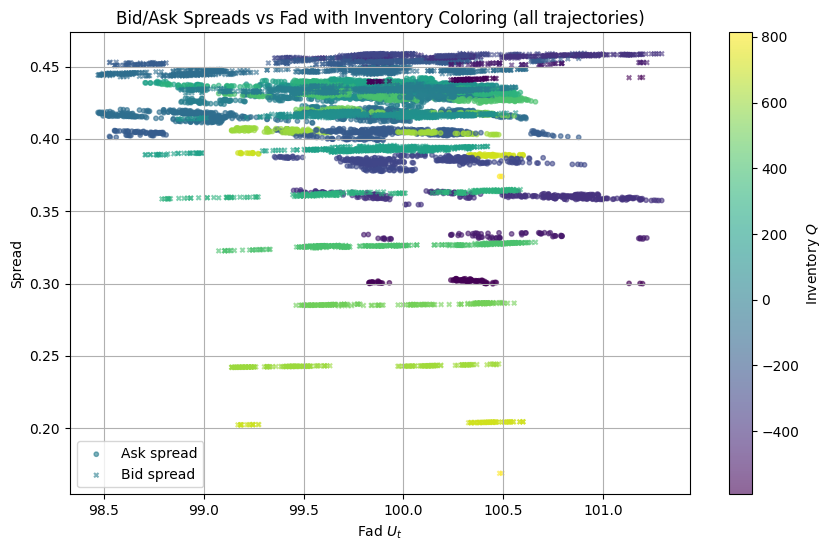

In [38]:
plot_actions_vs_fad_colored(observations_rl, actions_rl, 10)

## Comparing the learnt policy to the optimal policy

In [40]:
# For the StableBaselinesTradingEnvironment
print("SB Environment Action Space:")
print(f"Shape: {sb_rl_env_train.action_space}")
print(f"Low bounds: {sb_rl_env_train.action_space.low}")
print(f"High bounds: {sb_rl_env_train.action_space.high}")

# For the original trading environment
print("\nOriginal Trading Environment Action Space:")
print(f"Shape: {rl_env_train.action_space}")
print(f"Low bounds: {rl_env_train.action_space.low}")
print(f"High bounds: {rl_env_train.action_space.high}")

SB Environment Action Space:
Shape: Box(0.0, 4.6051702, (2,), float32)
Low bounds: [0. 0.]
High bounds: [4.6051702 4.6051702]

Original Trading Environment Action Space:
Shape: Box(0.0, 4.6051702, (2,), float32)
Low bounds: [0. 0.]
High bounds: [4.6051702 4.6051702]


In [41]:
# Auxiliary function for normalization of inventories
def normalize_inventory(inventories, max_inventory, use_normalized=False, inverse=False):
    if not use_normalized:
        return inventories

    inventory_low = -max_inventory
    gradient_inventory = (max_inventory - inventory_low) / 2  

    if inverse:
        # Denormalize: from [-1, 1] back to original scale
        return (inventories + 1) * gradient_inventory + inventory_low
    else:
        # Normalize: from [-max_inventory, max_inventory] to [-1, 1]
        return (inventories - inventory_low) / gradient_inventory - 1

In [42]:
inventories = np.arange(-4,5,1)
inventories_normalised = normalize_inventory(inventories, max_inventory, use_normalized=use_normalized_agent, inverse=False)

In [43]:
ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_evaluation, use_normalized_agent=use_normalized_agent) 

In [44]:
bid_actions = []
ask_actions = []
for inventory in inventories_normalised:
    if use_normalized_agent:
        state = np.array([[inventory, 0,  0 , 0]])   # attention here for normalised agent maybe it is -1 instead of 0
    else:
        state = np.array([[inventory, 0.5, 100, 0]])
    bid_action, ask_action = ppo_agent.get_action(state).reshape(-1)
    bid_actions.append(bid_action)
    ask_actions.append(ask_action)       

In [45]:
full_info_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=get_closed_form_env())

✓ Pre-computed ODE solutions for 1000 time points


In [46]:
# Get the Full Information action
fi_bid_actions = []
fi_ask_actions = []
for inventory in inventories:
    bid_action, ask_action = full_info_agent.get_action(np.array([[0,inventory,0.5,100,0]])).reshape(-1)
    fi_bid_actions.append(bid_action)
    fi_ask_actions.append(ask_action)

Policy comparison plot saved to .././Full_Info_models/PPO-best-FI/FIMm_finalVersion_prova/2025-12-01_12-15-33/policy_comparison.png


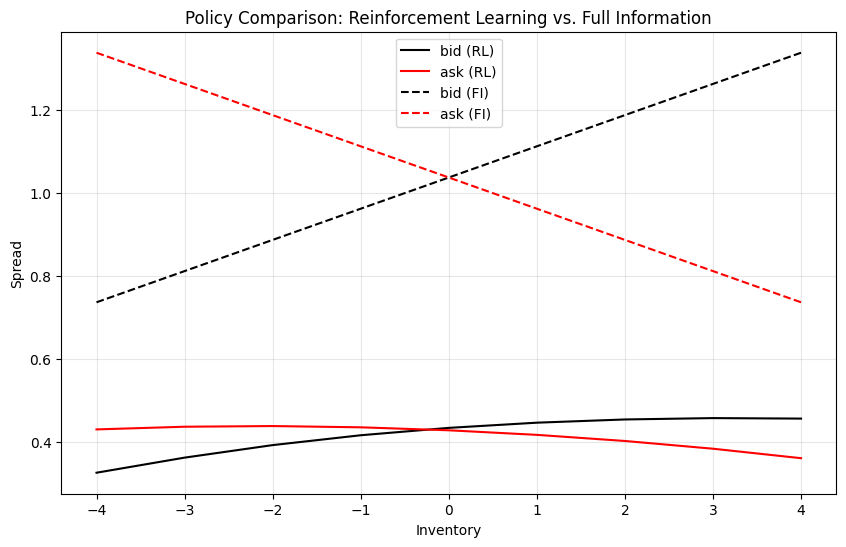

In [47]:
# Create a policy comparison plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(inventories, bid_actions, label="bid (RL)", color="k")
ax.plot(inventories, ask_actions, label="ask (RL)", color="r")
ax.plot(inventories, fi_bid_actions, label="bid (FI)", color="k", linestyle="--")
ax.plot(inventories, fi_ask_actions, label="ask (FI)", color="r", linestyle="--")
ax.legend()
ax.set_xlabel("Inventory")
ax.set_ylabel("Spread")
ax.set_title("Policy Comparison: Reinforcement Learning vs. Full Information")
ax.grid(alpha=0.3)

# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Save the figure to the best model path
policy_comparison_filename = os.path.join(best_model_path, "policy_comparison.png")
fig.savefig(policy_comparison_filename, dpi=300, bbox_inches='tight')
print(f"Policy comparison plot saved to {policy_comparison_filename}")

## Dependence of policy on time

In [48]:
# Function to create the plot comparing PPO and FI agents
def plot_policy_time_dependence(ppo_agent, fi_agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1) 
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  
    ax2 = plt.subplot(gs[0, 1])  
    ax3 = plt.subplot(gs[1, 0])  
    ax4 = plt.subplot(gs[1, 1]) 
    
    price = 100.0  
    if use_normalized_agent:
        price_normalized = 0 
    else:
        price_normalized = price
    
    filtered_fad = 0.0
    if use_normalized_agent:
        filtered_fad_normalized = -1
    else:
        filtered_fad_normalized = filtered_fad

    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        fi_bids = []
        fi_asks = []
        
        inv_normalised = normalize_inventory(inv, max_inventory, use_normalized=use_normalized_agent, inverse=False)

        # For each time point
        for t in times:
            if use_normalized_agent:
                normalized_time = (t) / (1/2) - 1
            else:   
                normalized_time = t
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv_normalised, normalized_time, price_normalized, filtered_fad_normalized]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)

            # Get FI agent's actions
            fi_bid, fi_ask = fi_agent.get_action(np.array([[0, inv, t, price, filtered_fad]])).reshape(-1)
            fi_bids.append(fi_bid)
            fi_asks.append(fi_ask)

        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, fi_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, fi_asks, label=f"Inventory = {inv}", color=colors[inv])

    ax1.set_title("RL δ^bid")
    ax2.set_title("FI δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("FI δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus approx. closed-form solution for the Full Information setting as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()

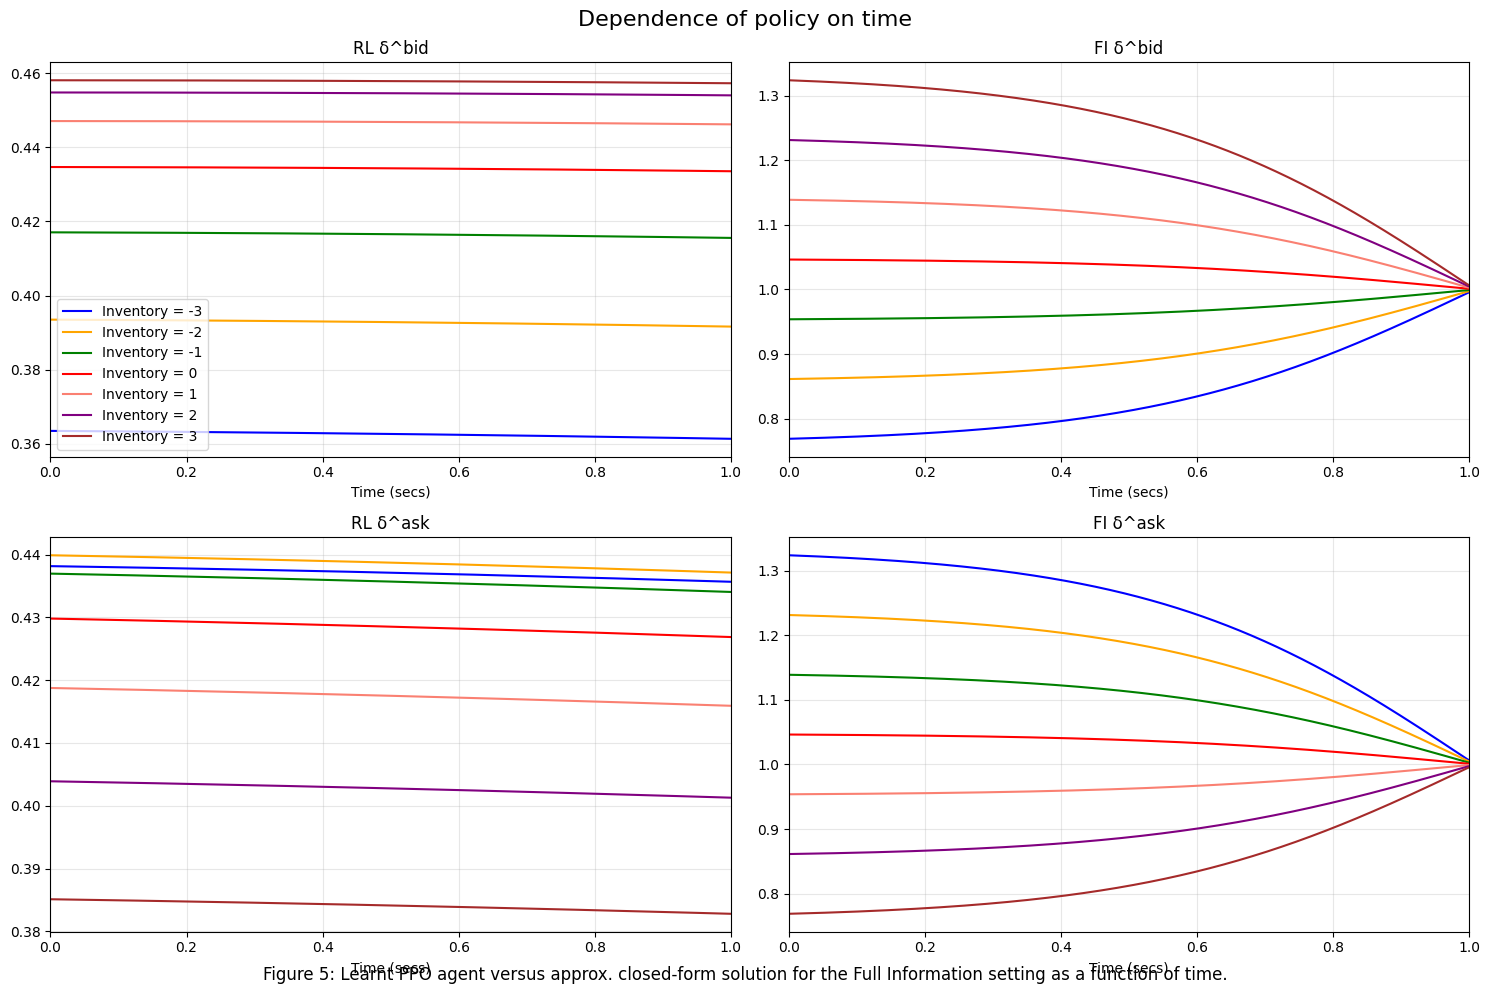

In [49]:
plot_policy_time_dependence(ppo_agent, full_info_agent)

In [50]:
def plot_policy_time_dependence(ppo_agent, agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  # 0 to 30 seconds
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  
    ax2 = plt.subplot(gs[0, 1])  
    ax3 = plt.subplot(gs[1, 0])  
    ax4 = plt.subplot(gs[1, 1])  
    
    price = 100.0  
    if use_normalized_agent:
        price_normalized = 0 
    else:
        price_normalized = price 

    filtered_fad = 0.0
    if use_normalized_agent:
        filtered_fad_normalized = -1
    else:
        filtered_fad_normalized = filtered_fad

    global_min = float('inf')
    global_max = float('-inf')
    
    all_data = []

    for inv in inventories:
        rl_bids = []
        rl_asks = []
        bids = []
        asks = []
        
        inv_normalised = normalize_inventory(inv, max_inventory, use_normalized=use_normalized_agent, inverse=False)

        # For each time point
        for t in times:
            if use_normalized_agent:
                normalized_time = (t) / (1/2) - 1
            else:   
                normalized_time = t
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv_normalised, normalized_time, price_normalized, filtered_fad_normalized]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)

            # Get agent's actions
            bid, ask = agent.get_action(np.array([[0, inv, t, price, filtered_fad]])).reshape(-1)
            bids.append(bid)
            asks.append(ask)

        global_min = min(global_min, min(rl_bids), min(rl_asks), min(bids), min(asks))
        global_max = max(global_max, max(rl_bids), max(rl_asks), max(bids), max(asks))

        all_data.append((inv, rl_bids, rl_asks, bids, asks))

    for inv, rl_bids, rl_asks, bids, asks in all_data:
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, asks, label=f"Inventory = {inv}", color=colors[inv])

    # Apply the same y-axis limits to all subplots
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(global_min, global_max)
    
    ax1.set_title("RL δ^bid")
    ax2.set_title("FI δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("FI δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus approx. closed-form solution for the Full Information setting as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()
    return fig

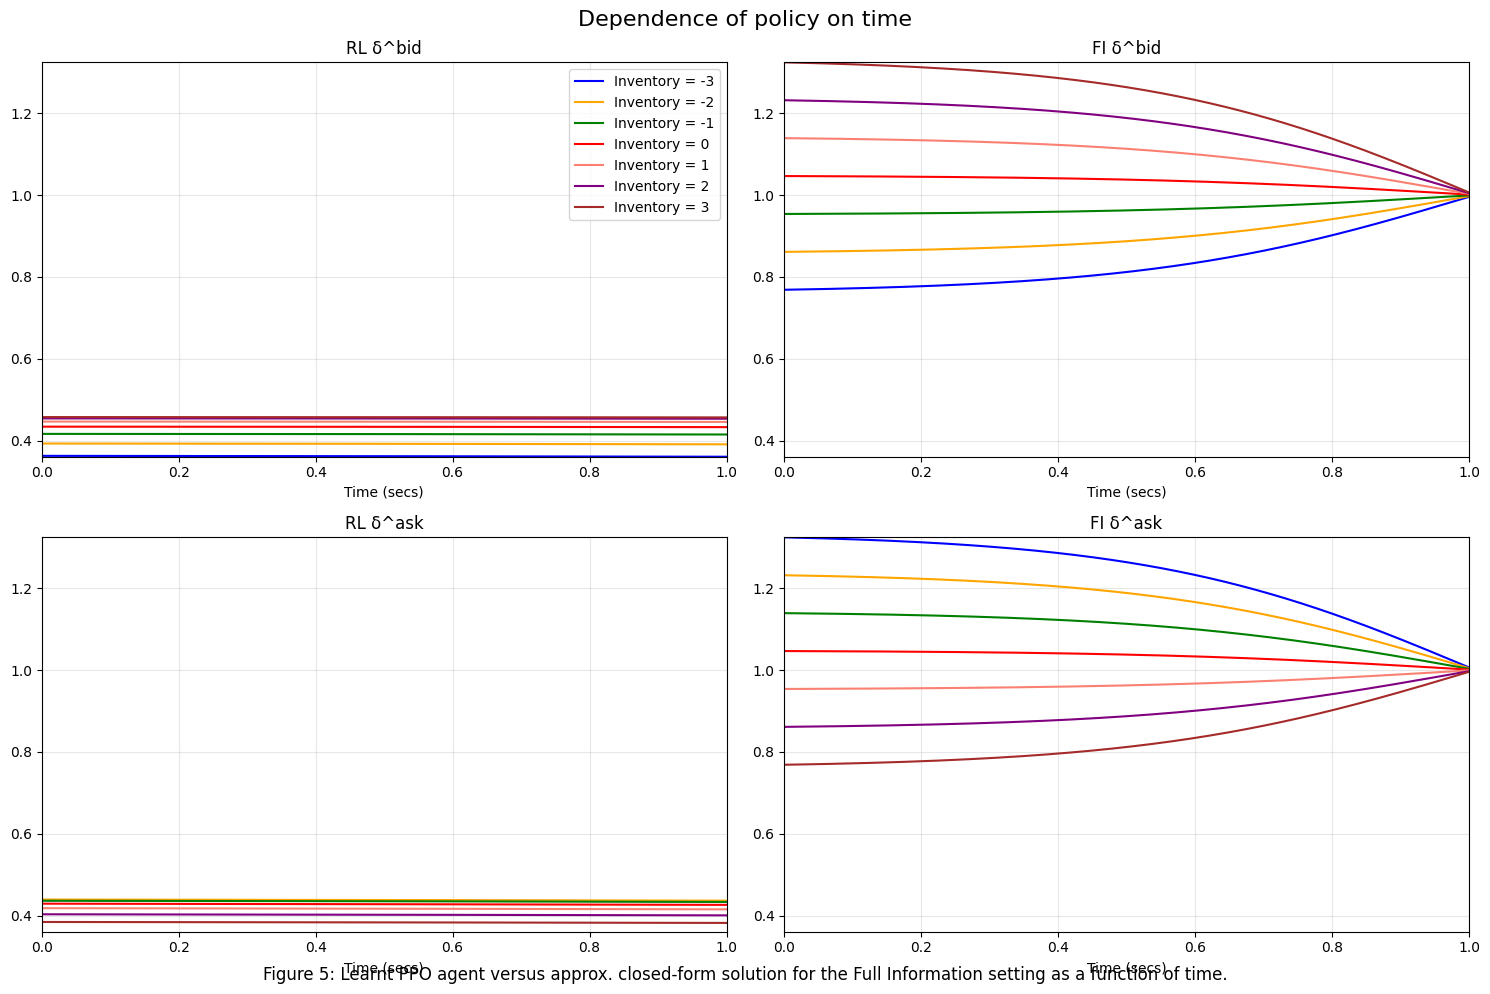

Plot saved to .././Full_Info_models/PPO-best-FI/FIMm_finalVersion_prova/2025-12-01_12-15-33/policy_time_dependence.png


In [51]:
# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Create the plot
fig = plot_policy_time_dependence(ppo_agent, full_info_agent)

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "policy_time_dependence.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

In [52]:
import glob
import os

def get_latest_event_file(logdir: str) -> str:
    # Recursively search for TensorBoard event files
    pattern = os.path.join(logdir, "**", "events.out.tfevents.*")
    event_files = glob.glob(pattern, recursive=True)
    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event files found under {logdir}")
    # Pick the most recently modified one
    latest_file = max(event_files, key=os.path.getmtime)
    return latest_file

Using event file: .././Full_Info_models/tensorboard/PPO-learning-FI/FIMm_finalVersion_prova/2025-12-01_12-15-33/PPO_1/events.out.tfevents.1764587734.MacBookAir.lan.58455.0


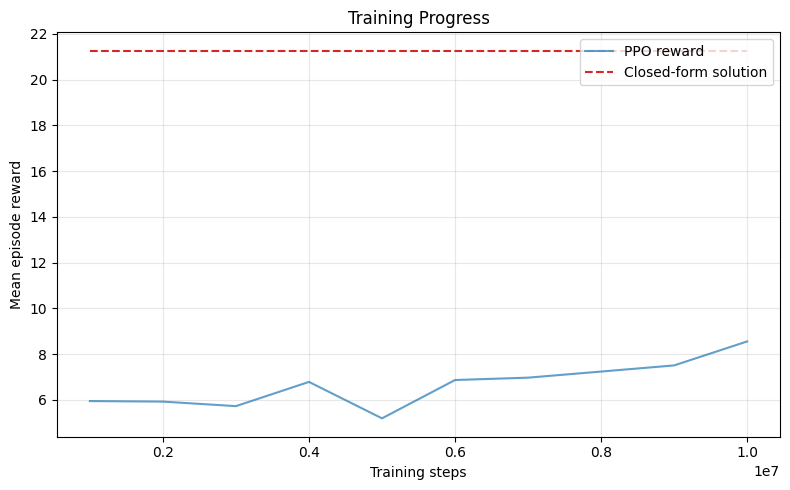

Plot saved to .././Full_Info_models/PPO-best-FI/FIMm_finalVersion_prova/2025-12-01_12-15-33/Training_process.png


In [53]:
# Load the event file
event_file = get_latest_event_file(tensorboard_logdir)
print(f"Using event file: {event_file}")

ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()
# Extract the rollout/ep_rew_mean data
tag = "rollout/ep_rew_mean"
events = ea.Scalars(tag)
steps = [event.step for event in events]
rewards = [event.value for event in events]

# Plot the rewards
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the rewards
ax.plot(steps, rewards, '-', color='tab:blue', label='PPO reward', alpha=0.7)

# Add the baseline from Cartea-Jaimungal
y_line = float(results_fi["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(steps), xmax=max(steps), 
          linestyles='--', color='tab:red',
          label='Closed-form solution')

# Formatting
plt.grid(alpha=0.3)
plt.xlabel('Training steps')
plt.ylabel('Mean episode reward')
plt.title('Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "Training_process.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

Using event file: .././Full_Info_models/tensorboard/PPO-learning-FI/FIMm_finalVersion_prova/2025-12-01_12-15-33/PPO_1/events.out.tfevents.1764587734.MacBookAir.lan.58455.0
Eval tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': ['eval/mean_ep_length', 'eval/mean_reward', 'rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}
Available tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': ['eval/mean_ep_length', 'eval/mean_reward', 'rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss'

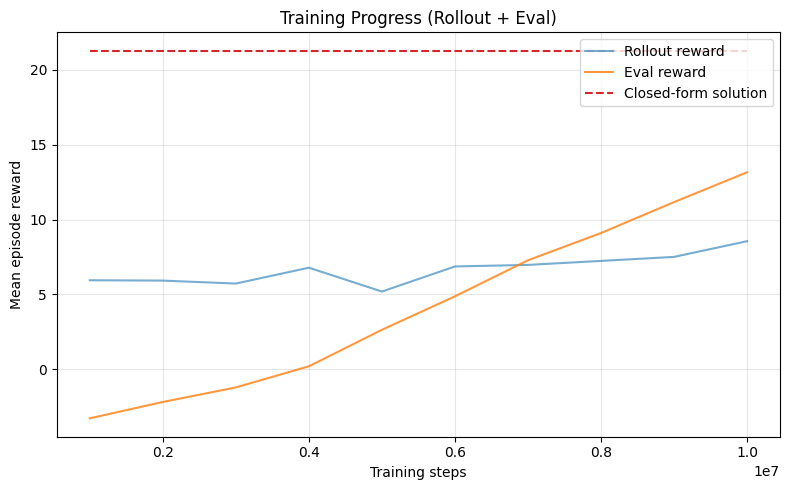

Plot saved to .././Full_Info_models/PPO-best-FI/FIMm_finalVersion_prova/2025-12-01_12-15-33/Training_process_rewards.png


In [54]:
# === Load rollout rewards ===
rollout_file = get_latest_event_file(tensorboard_logdir)
print(f"Using event file: {rollout_file}")
ea_rollout = event_accumulator.EventAccumulator(rollout_file)
ea_rollout.Reload()

# === Load eval rewards ===
eval_file = rollout_file  # same file if training and eval in same run
ea_eval = event_accumulator.EventAccumulator(eval_file)
ea_eval.Reload()
print("Eval tags:", ea_eval.Tags())

# Extract rollout and eval data
rollout_tag = "rollout/ep_rew_mean"
eval_tag = "eval/mean_reward"

# Make sure both tags exist
print("Available tags:", ea_rollout.Tags())

rollout_events = ea_rollout.Scalars(rollout_tag)
eval_events = ea_eval.Scalars(eval_tag)

rollout_steps = [e.step for e in rollout_events]
rollout_rewards = [e.value for e in rollout_events]

eval_steps = [e.step for e in eval_events]
eval_rewards = [e.value for e in eval_events]

# === Plot both ===
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(rollout_steps, rollout_rewards, '-', color='tab:blue', label='Rollout reward', alpha=0.6)
ax.plot(eval_steps, eval_rewards, '-', color='tab:orange', label='Eval reward', alpha=0.8)

# Add baseline line
y_line = float(results_fi["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(rollout_steps + eval_steps), xmax=max(rollout_steps + eval_steps),
          linestyles='--', color='tab:red', label='Closed-form solution')

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Training Progress (Rollout + Eval)')
ax.legend()
plt.tight_layout()
plt.show()

# Save the figure
plot_filename = os.path.join(best_model_path, "Training_process_rewards.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")